In [1]:
pip install pandas numpy scikit-learn gymnasium stable-baselines3 matplotlib


Note: you may need to restart the kernel to use updated packages.


   Production Year Production Date Entered                         Operator  \
0             1995               12/3/1996              Buffalo China, Inc.   
1             1995               3/29/1996           Copper Ridge Oil, Inc.   
2             1994               2/14/1995  White, Walter W. & Christina L.   
3             1994               1/19/1995              Stiegler, Richard M   
4             1995               2/12/1996                Bucher, Charles J   

        County         Town                    Field Producing Formation  \
0         Erie      BUFFALO                  BUFFALO              MEDINA   
1      Steuben   WEST UNION  BEECH HILL-INDEPENDENCE       FULMER VALLEY   
2  Cattaraugus   CARROLLTON                 BRADFORD            BRADFORD   
3         Erie  CHEEKTOWAGA                  BUFFALO              MEDINA   
4  Cattaraugus     ALLEGANY                FIVE MILE            BRADFORD   

   Active Oil Wells  Inactive Oil Wells  Active Gas Wells  Inactive 

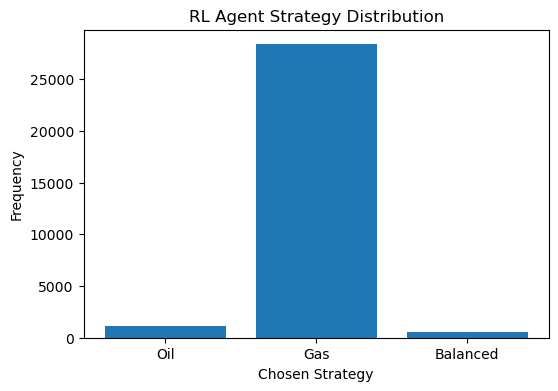


First 20 Decisions
Step  1 --> Prioritize Gas
Step  2 --> Prioritize Gas
Step  3 --> Prioritize Gas
Step  4 --> Prioritize Gas
Step  5 --> Prioritize Gas
Step  6 --> Prioritize Gas
Step  7 --> Prioritize Gas
Step  8 --> Prioritize Gas
Step  9 --> Prioritize Oil
Step 10 --> Prioritize Gas
Step 11 --> Prioritize Gas
Step 12 --> Prioritize Gas
Step 13 --> Prioritize Gas
Step 14 --> Prioritize Gas
Step 15 --> Prioritize Gas
Step 16 --> Prioritize Gas
Step 17 --> Prioritize Gas
Step 18 --> Prioritize Gas
Step 19 --> Prioritize Gas
Step 20 --> Prioritize Gas

Finished.


In [1]:
# ==========================================================
# Reinforcement Learning on Oil & Gas Production Dataset
# ==========================================================

# Install if needed:
# pip install pandas numpy scikit-learn gymnasium stable-baselines3 matplotlib

import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import DQN

import matplotlib.pyplot as plt

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("oil-and-gas-summary-production-data-1967-1999-1.csv")

print(df.head())

print("\nColumns:")
print(df.columns)

# ==========================================================
# Select Features
# ==========================================================

features = [
    "Active Oil Wells",
    "Active Gas Wells",
    "Oil Produced, bbl",
    "Gas Produced, Mcf",
    "Water produced, bbl"
]

df = df[features]

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))

# ==========================================================
# Normalize Features
# ==========================================================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

# ==========================================================
# Custom Reinforcement Learning Environment
# ==========================================================

class OilProductionEnv(gym.Env):

    metadata = {"render_modes": ["human"]}

    def __init__(self, data):

        super(OilProductionEnv, self).__init__()

        self.data = data

        self.current_step = 0

        # Three production strategies
        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(data.shape[1],),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.current_step = 0

        observation = self.data[self.current_step]

        return observation.astype(np.float32), {}

    def step(self, action):

        state = self.data[self.current_step]

        oil = state[2]
        gas = state[3]
        water = state[4]

        # --------------------------------------------------
        # Reward Function
        # --------------------------------------------------

        if action == 0:
            # Prioritize oil
            reward = (2 * oil) - water

        elif action == 1:
            # Prioritize gas
            reward = (2 * gas) - water

        else:
            # Balanced production
            reward = oil + gas - 0.5 * water

        self.current_step += 1

        terminated = self.current_step >= len(self.data) - 1

        truncated = False

        next_state = self.data[min(self.current_step, len(self.data)-1)]

        return (
            next_state.astype(np.float32),
            float(reward),
            terminated,
            truncated,
            {}
        )

    def render(self):

        print(f"Step : {self.current_step}")

# ==========================================================
# Create Environment
# ==========================================================

env = OilProductionEnv(scaled_data)

# ==========================================================
# Train DQN Agent
# ==========================================================

model = DQN(
    policy="MlpPolicy",
    env=env,
    learning_rate=0.001,
    buffer_size=10000,
    learning_starts=500,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    target_update_interval=500,
    exploration_fraction=0.1,
    verbose=1
)

model.learn(total_timesteps=20000)

print("\nTraining Completed!")

# ==========================================================
# Evaluate Agent
# ==========================================================

obs, info = env.reset()

done = False

total_reward = 0

actions = []

while not done:

    action, _ = model.predict(obs)

    actions.append(int(action))

    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward

    done = terminated or truncated

print("\nTotal Reward :", total_reward)

# ==========================================================
# Show Action Distribution
# ==========================================================

actions = np.array(actions)

print("\nAction Counts")

print("Prioritize Oil :", np.sum(actions == 0))
print("Prioritize Gas :", np.sum(actions == 1))
print("Balanced       :", np.sum(actions == 2))

# ==========================================================
# Plot Action Distribution
# ==========================================================

plt.figure(figsize=(6,4))

plt.hist(actions, bins=[-0.5,0.5,1.5,2.5], rwidth=0.8)

plt.xticks([0,1,2],["Oil","Gas","Balanced"])

plt.xlabel("Chosen Strategy")

plt.ylabel("Frequency")

plt.title("RL Agent Strategy Distribution")

plt.show()

# ==========================================================
# Display First 20 Decisions
# ==========================================================

print("\nFirst 20 Decisions")

obs, info = env.reset()

done = False

step = 0

while not done and step < 20:

    action, _ = model.predict(obs)

    strategy = {
        0:"Prioritize Oil",
        1:"Prioritize Gas",
        2:"Balanced"
    }[int(action)]

    print(f"Step {step+1:2d} --> {strategy}")

    obs, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    step += 1

print("\nFinished.")

In [3]:
pip install pandas nltk scikit-learn transformers torch sentence-transformers scipy

  Using cached transformers-5.12.1-py3-none-any.whl.metadata (33 kB)
  Using cached sentence_transformers-5.6.0-py3-none-any.whl.metadata (18 kB)
  Using cached huggingface_hub-1.21.0-py3-none-any.whl.metadata (14 kB)
  Using cached regex-2026.6.28-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached hf_xet-1.5.1-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
Using cached transformers-5.12.1-py3-none-any.whl (11.2 MB)
Using cached huggingface_hub-1.21.0-py3-none-any.whl (721 kB)
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   ------------- -------------------------- 1.3/4.0 MB 5.5 MB/s eta 0:00:01
   -------------------- ------------------- 2.1/4.0 MB 4.6 MB/s eta 0:00:01
   ----------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [4]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

from sentence_transformers import SentenceTransformer

# --------------------------------------------------
# Download NLTK Resources
# --------------------------------------------------

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

df = pd.read_csv("emotion-labels-test.csv")

print(df.head())

text = df["text"].astype(str)
labels = df["label"]

# --------------------------------------------------
# Label Encoding
# --------------------------------------------------

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

# --------------------------------------------------
# NLP Preprocessing
# --------------------------------------------------

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(sentence):

    sentence = sentence.lower()

    sentence = re.sub(r"http\S+", "", sentence)
    sentence = re.sub(r"@\w+", "", sentence)
    sentence = re.sub(r"[^a-zA-Z ]", " ", sentence)

    tokens = word_tokenize(sentence)

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

clean_text = text.apply(preprocess)

# --------------------------------------------------
# TF-IDF Features
# --------------------------------------------------

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    sublinear_tf=True
)

tfidf_features = tfidf.fit_transform(clean_text)

print("TF-IDF Shape:", tfidf_features.shape)

# --------------------------------------------------
# Transfer Learning (BERT)
# --------------------------------------------------

bert = SentenceTransformer("all-MiniLM-L6-v2")

bert_embeddings = bert.encode(
    clean_text.tolist(),
    show_progress_bar=True
)

print("BERT Shape:", bert_embeddings.shape)

# --------------------------------------------------
# Combine TF-IDF + BERT
# --------------------------------------------------

X = hstack([tfidf_features, bert_embeddings])

print("Combined Shape:", X.shape)

# --------------------------------------------------
# Train Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Train Classifier
# --------------------------------------------------

model = LogisticRegression(
    max_iter=5000
)

model.fit(X_train, y_train)

# --------------------------------------------------
# Prediction
# --------------------------------------------------

pred = model.predict(X_test)

# --------------------------------------------------
# Evaluation
# --------------------------------------------------

print()

print("Accuracy")

print(accuracy_score(y_test, pred))

print()

print(classification_report(
    y_test,
    pred,
    target_names=encoder.classes_
))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SruthinJayakumaran\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SruthinJayakumaran\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SruthinJayakumaran\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SruthinJayakumaran\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\SruthinJayakumaran\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package omw-1.4 is already up-to-date!


                                                text label
0  You must be knowing #blithe means (adj.)  Happ...   joy
1  Old saying 'A #smile shared is one gained for ...   joy
2  Bridget Jones' Baby was bloody hilarious 😅 #Br...   joy
3  @Elaminova sparkling water makes your life spa...   joy
4  I'm tired of everybody telling me to chill out...   joy
TF-IDF Shape: (3142, 10000)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\SruthinJayakumaran\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SruthinJayakumaran\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/99 [00:00<?, ?it/s]

BERT Shape: (3142, 384)
Combined Shape: (3142, 10384)

Accuracy
0.7821939586645469

              precision    recall  f1-score   support

       anger       0.81      0.76      0.78       152
        fear       0.76      0.82      0.79       199
         joy       0.82      0.84      0.83       143
     sadness       0.76      0.69      0.72       135

    accuracy                           0.78       629
   macro avg       0.78      0.78      0.78       629
weighted avg       0.78      0.78      0.78       629

